# Exercises for Chapter 16: Design and sample size decisions

In [2]:
import os
import sys

import numpy

from matplotlib import pyplot
from scipy import stats

sys.path.append(os.path.abspath("/home/bgawalt/ros"))
import bg_ros

In [3]:
prng_builder = bg_ros.PRNGBuilder("""
    Chapter 16: Design and sample size decisions

    This is fun - it's hard to really remember where this chapter
    begins and chapter 4 ends.  Mostly because this is focused on the
    most fun parts of chapter 4, expanding on them.  I think we get
    the clearest case against statsig chasing ('you're going to treat
    it like infinite lottery tickets').
""")

## 16.1, Sample size calculations for estimating a proportion

> (a) How large a sample survey would be required to estimate, to within a
>     standard error of $\pm$3%, the proportion of the U.S. population who
>     support the death penalty?
>
> (b) About 14% of the U.S. population is Latino. How large would a national
>     sample of Americans have to be in order to estimate, to within a standard
>     error of $\pm$3%, the proportion of Latinos in the United States who
>     support the death penalty?
>
> (c) How large would a national sample of Americans have to be in order to
>     estimate, to within a standard error of $\pm$1%, the proportion who are
>     Latino?

In [4]:
print(numpy.sqrt(0.14 * (1 - 0.14)))
print(2*numpy.sqrt(0.14 * (1 - 0.14)))

0.34698703145794946
0.6939740629158989


In [5]:
a = 0.14
b = -2 * numpy.sqrt(0.14 * (1 - 0.14))
c = -278

In [6]:
print(-b / (2 * a))
print(1 / (2 * a))
print(b ** 2 - 4 * a * c)
z = -b / (2 * a) + (1 / (2 * a)) * numpy.sqrt(b ** 2 - 4 * a * c)
print(z)
print(z ** 2)

2.47847879612821
3.571428571428571
156.1616
47.10870558086618
2219.2301415047323


In [7]:
print(278 * 7)

1946


In [8]:
print((numpy.sqrt(0.14 * (1 - 0.14)) / 0.01) ** 2)

1204.0


### 16.2, Sample size calculation for estimating a difference

> Consider an election with two major candidates, A and B, and a minor
> candidate, C, who are believed to have support of approximately 45%, 35%, and
> 20% in the population. A poll is to be conducted with the goal of estimating
> the difference in support between candidates A and B. How large a sample would
> you estimate is needed to estimate this difference to within a standard error
> of 5 percentage points? (Hint: consider an outcome variable that is coded as
> +1, -1, and 0 for supporters of A, B, and C, respectively.)

In [9]:
print(numpy.sqrt(0.6))
print(0.45 / 0.7)
print(0.6/ (0.05 * 0.05))

0.7745966692414834
0.6428571428571429
239.99999999999994


In [10]:
print(240 * (0.8 - 2 * numpy.sqrt(0.8 * 0.2 / 240)))
print(240 * (0.8 + 2 * numpy.sqrt(0.8 * 0.2 / 240)))

179.60645329213628
204.39354670786375


In [11]:
p = 0.45 / 0.7
print(numpy.sqrt(p * (1 - p) / 180))

0.03571428571428571


In [12]:
print(round(100.92342))

101


## 16.3, Power

> Following Figure 16.3, determine the power (the probability of getting an
> estimate that is "statistically significantly" different from zero at the 5%
> level) of a study where the true effect size is X standard errors from zero.
> Answer for the following values of X: 0, 1, 2, and 3.

In [13]:
for x in [0, 1, 2, 3]:
    power = stats.norm.sf(1.96, loc=x, scale=1)
    print(f' {x} | {int(round(100 * power))}' + '%')

 0 | 2%
 1 | 17%
 2 | 52%
 3 | 85%


## 16.4, Power, type M error, and type S error

> Consider the experiment shown in Figure 16.1 where the true effect could not
> realistically be more than 2 percentage points and it is estimated with a
> standard error of 8.1 percentage points.
>
> (a) Assuming the estimate is unbiased and normally distributed and the true
>     effect size is 2 percentage points, use simulation to answer the following
>     questions: What is the power of this study? If only "statistically
>     significant" results are reported, what is the average type M error and
>     what is the type S error rate?
>
> (b) Assuming the estimate is unbiased and normally distributed and the true
>     effect size is no more than 2 percentage points in absolute value, what
>     can you say about the power, average type M error, and type S error rate?

In [14]:
rng = prng_builder.new('Exercise 16.4, Power, type M error, and type S error')

In [15]:
n = 10_000
estimates = stats.norm.rvs(loc=2, scale=8.1, size=n, random_state=rng)
statsig = [e for e in estimates if abs(e) > (8.1 * 2)]
print(f'Power: {round(100 * float(len(statsig)) / n)}' + '%')
print(f'Avg. type M: {numpy.mean([e / 2 for e in statsig if e > 0]):0.1f}')
print(f'Type S rate: {100 * float(len([e for e in statsig if e < 0])) / n:0.1f}' + '%')

Power: 5%
Avg. type M: 9.7
Type S rate: 1.3%


In [16]:
mus = numpy.linspace(-2, 2, 60)
ps = []
ms = []
ss = []
for mu in mus:
    n = 100_000
    estimates = stats.norm.rvs(loc=mu, scale=8.1, size=n, random_state=rng)
    statsig = [e for e in estimates if abs(e) > (8.1 * 2)]
    power = float(len(statsig)) / n
    avg_m = numpy.mean([e / mu for e in statsig if (e / mu) > 0])
    srate = float(len([e for e in statsig if (e / mu) < 0])) / n
    ps.append(power)
    ms.append(avg_m)
    ss.append(srate)

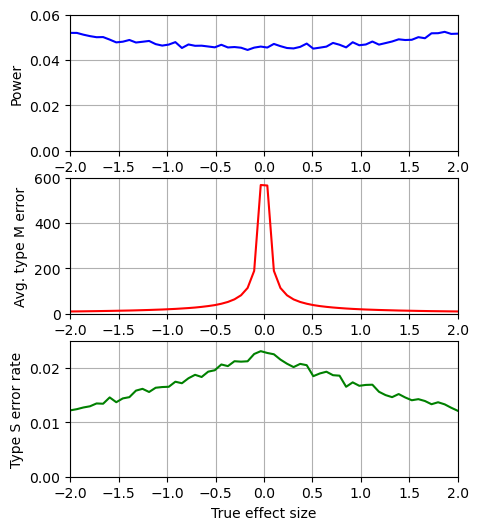

In [17]:
fig, axs = pyplot.subplots(nrows=3, ncols=1, figsize=(5, 6))
axs[0].plot(mus, ps, 'b-')
axs[0].set_ylabel('Power')
axs[0].set_ylim(0, 0.06)

axs[1].plot(mus, ms, 'r-')
axs[1].set_ylabel('Avg. type M error')
axs[1].set_ylim(0, 600)

axs[2].plot(mus, ss, 'g-')
axs[2].set_ylabel('Type S error rate')
axs[2].set_ylim(0, 0.025)

for ax in axs:
    ax.grid()
    ax.set_axisbelow(True)
    ax.set_xlabel('True effect size')
    ax.set_xlim(-2, 2)

## 16.5, Design analysis for an experiment

> You conduct an experiment in which half the people get a special
> get-out-the-vote message and others do not. Then you follow up after the
> election with a random sample of 500 people to see if they voted.
>
> (a) What will be the standard error of your estimate of effect size? Figure
>     this out making reasonable assumptions about voter turnout and the true
>     effect size.
>
> (b) Check how sensitive your standard error calculation is to your
>     assumptions.
>
> (c) For a range of plausible effect sizes, consider conclusions from this
>     study, in light of the statistical significance filter. As a researcher,
>     how can you avoid this problem?

In [20]:
def se(true_effect: float, baseline_turnout: float):
    p1 = baseline_turnout
    p2 = baseline_turnout + true_effect
    return numpy.sqrt(p1 * (1 - p1) / 250 + p2 * (1 - p2) / 250)

In [22]:
trues = numpy.linspace(-0.01, 0.03, 150)
ses = {
    base: [se(true_effect=te, baseline_turnout=base) for te in trues]
    for base in [0.4, 0.5, 0.6]
}

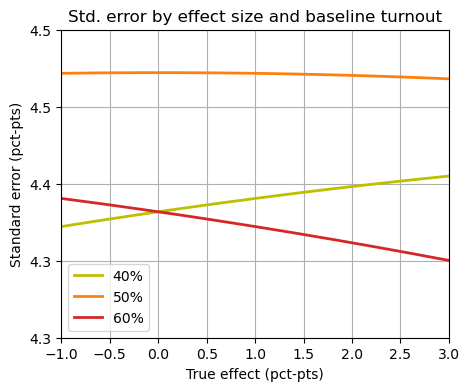

In [42]:
fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
for base, color in zip(sorted(ses.keys()), ['y', 'tab:orange', 'tab:red']):
    ax.plot(
        [100 * t for t in trues],
        [100 * se for se in ses[base]],
        color=color,
        markersize=0,
        linewidth=2,
        linestyle='-',
        label=f'{round(100 * base)}' + '%'
    )
ax.set_xlim(-1, 3)
ax.set_ylim(4.3, 4.5)
ax.set_title('Std. error by effect size and baseline turnout')
ax.set_ylabel('Standard error (pct-pts)')
ax.set_xlabel('True effect (pct-pts)')
ax.set_yticks(
    [4.3, 4.35, 4.4, 4.45, 4.5],
    [f'{f:0.2}' for f in [4.3, 4.35, 4.4, 4.45, 4.5]],
)
ax.grid()
ax.legend()

## 16.6, Design analysis with pre-treatment information

> A new teaching method is hoped to increase scores by 5 points on a certain
> standardized test. An experiment is performed on $n$ students, where half get
> this intervention and half get the control. Suppose that the standard
> deviation of test scores in the population is 20 points. Further suppose that
> a pre-test is available which has a correlation of 0.8 with the post-test
> under the control condition. What will be the standard error of the estimated
> treatment effect based on a fitted regression, assuming that the treatment
> effect is constant and independent of the value of the pre-test?

In [44]:
0.36*400

144.0

In [48]:
4*144

576

In [49]:
n = round(2 * (144 + 144) * ((2.8/5)**2))
print(f'{2.8*numpy.sqrt(576/n):0.2f}')

4.99


## 16.8, Effect size and sample size

> Consider a toxin that can be tested on animals at different doses. Suppose a
> typical exposure level for humans is 1 (in some units), and at this level the
> toxin is hypothesized to introduce a risk of 0.01% of death per person.
>
> (a) Consider different animal studies, each time assuming a linear
>     dose-response relation (that is, 0.01% risk of death per animal per unit
>     of the toxin), with doses of 1, 100, and 10,000. At each of these exposure
>     levels, what sample size is needed to have 80% power of detecting the
>     effect?
>
> (b) This time assume that response is a logged function of dose and redo the
>     calculations in (a).

In [50]:
2*2.8*2.8

15.679999999999998

In [53]:
for dose in [1, 100, 10_000]:
    p = 0.01 * 0.01 * dose
    n = 2 * 2.8 * 2.8 * (1 - p) / p
    print(f'{str(dose).ljust(6)} | {100*p:0.2f} | {round(n)}')

1      | 0.01 | 156784
100    | 1.00 | 1552
10000  | 100.00 | 0


In [65]:
for dose in [1, 100, 10_000]:
    alpha = numpy.expm1(0.01 * 0.01)
    p = numpy.log(1 + alpha * dose)
    n = 2 * 2.8 * 2.8 * (1 - p) / p
    print(f'{str(dose).ljust(6)} | {100*p:0.2f} | {round(n)}')

1      | 0.01 | 156784
100    | 1.00 | 1560
10000  | 69.32 | 7


In [74]:
1 - (1 - 0.69) ** 3

0.970209

## 16.9, Cluster sampling with equal-sized clusters

> A survey is being planned with the goal of interviewing $n$ people in some
> number $J$ of clusters. For simplicity, assume simple random sampling of
> clusters and a simple random sample of size $n/J$ (appropriately rounded)
> within each sampled cluster.
>
> Consider inferences for the proportion of Yes responses in the population for
> some question of interest. The estimate will be simply the average response
> for the $n$ people in the sample.
>
> Suppose that the true proportion of Yes responses is not too far from 0.5 and
> that the standard deviation among the mean responses of clusters is 0.1.
>
> (a) Suppose the total sample size is $n = 1000$. What is the standard error
>     for the sample average if $J = 1000$? What if $J = 100, 10, 1$?
>
> (b) Suppose the cost of the survey is 50 dollars per interview, plus 500 per
>     cluster. Further suppose that the goal is to estimate the proportion of
>     Yes responses in the population with a standard error of no more than 2%.
>     What values of $n$ and $J$ will achieve this at the lowest cost?

In [79]:
alpha = (0.1 ** (-2) - 1) / 8
print(alpha)
print(2*alpha)
print(8*alpha + 4)

12.374999999999998
24.749999999999996
102.99999999999999


In [80]:
def se_p(n: int, j: int) -> float:
    return numpy.sqrt((24.75 * j + n ) / (103 * j * n))

for j in [1000, 100, 10, 1]:
    print(f'{str(j).ljust(4)} | {100 * se_p(n=1000, j=j):0.01f}' + '%')

1000 | 1.6%
100  | 1.8%
10   | 3.5%
1    | 10.0%


In [83]:
print(0.02 * 0.02 * 103)
print(1 / (0.02 * 0.02 * 103))

0.0412
24.271844660194173


In [82]:
24.75*50

1237.5

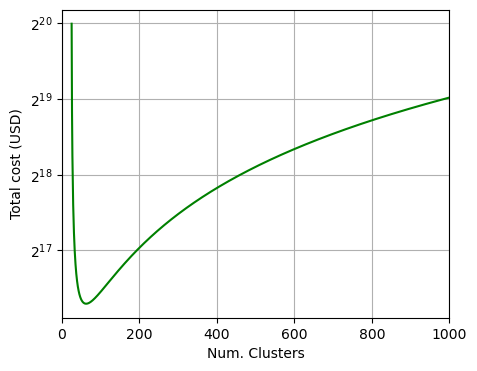

In [89]:
def cost(j: int) -> float:
    n = (24.75 * j) / (0.0412 * j - 1)
    return 500 * j + 50 * n

js = range(25, 1001)
cs = [cost(j) for j in js]

fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
ax.set_xlabel('Num. Clusters')
ax.set_ylabel('Total cost (USD)')
ax.semilogy(js, cs, 'g-', base=2)
ax.set_xlim(0, 1000)
ax.grid()

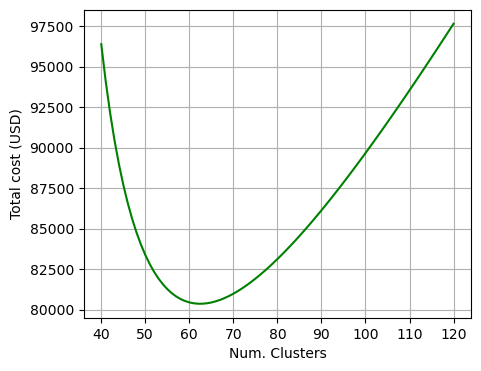

In [104]:
js = range(40, 121)
cs = [cost(j) for j in js]

fig = pyplot.figure(figsize=(5, 4))
ax = fig.gca()
ax.set_xlabel('Num. Clusters')
ax.set_ylabel('Total cost (USD)')
ax.plot(js, cs, 'g-')
ax.grid()

In [101]:
js[numpy.argmin(cs)]

62

In [102]:
(24.75 * 60) / (0.0412 * 60 - 1)

1008.8315217391305

In [103]:
print(cost(62))

80359.881626351
